# 📘 Question 5: Multi-Layer Perceptron (MLP) Architecture Comparison on Iris Dataset
### Comparing 1 Hidden Layer (8 Neurons) vs. 2 Hidden Layers (8, 4 Neurons)

---
**Course:** MCA Machine Learning (MCA521)  
**Author:** Vishwas Vashishtha | **Register No:** 2547255  
**Course Outcome:** CO5 | **Bloom's Taxonomy Level:** L4 (Analyzing & Evaluating)  

---

### 🎯 Problem Statement & Aim:
Develop, train, and compare two Multi-Layer Perceptron (MLP) neural network classifiers on the Iris dataset:
1. **Model 1:** One hidden layer with 8 neurons `(8,)`
2. **Model 2:** Two hidden layers with 8 and 4 neurons `(8, 4)`
- Evaluate both architectures using **5-Fold Stratified Cross-Validation**.
- Select the superior model based on cross-validation performance.
- Assess test performance using **accuracy** and a **labeled confusion matrix**.
- Document the step-by-step program execution flow.

## 1. Environment Setup & Core Dependencies

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Set seed for exact reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting aesthetics
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

## 2. Step 1: Dataset Ingestion & Class Balance Inspection
Fisher's Iris dataset contains 150 samples across 4 continuous morphological features and 3 balanced flower classes (50 Setosa, 50 Versicolor, 50 Virginica).

In [2]:
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
feature_names = list(iris.feature_names)
target_names = [str(name) for name in iris.target_names]

print(f"Dataset Shape   : {X.shape[0]} samples, {X.shape[1]} features")
print(f"Feature Names   : {feature_names}")
print(f"Target Classes  : {len(target_names)} classes ({target_names})")
print(f"Class Counts    : {dict(pd.Series(y).value_counts().sort_index())} (50 samples each)")

display(X.head())

Dataset Shape   : 150 samples, 4 features
Feature Names   : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Classes  : 3 classes (['setosa', 'versicolor', 'virginica'])
Class Counts    : {0: np.int64(50), 1: np.int64(50), 2: np.int64(50)} (50 samples each)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 3. Step 2: Stratified Train-Test Split (80% / 20%)
We partition data into 80% train ($N=120$) and 20% test ($N=30$) with stratification on $y$ to preserve equal class representation (10 samples per class in test).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Training Samples : {X_train.shape[0]} (40 per class)")
print(f"Testing Samples  : {X_test.shape[0]} (10 per class)")

Training Samples : 120 (40 per class)
Testing Samples  : 30 (10 per class)


## 4. Step 3: Neural Network Architectures & Mathematical Complexity

Both architectures utilize the **ReLU** activation function in hidden layers, **Softmax** cross-entropy loss, and the **Adam** optimizer (`learning_rate_init = 0.01`):

### Trainable Parameter Calculations:
1. **Model 1 [1 Hidden Layer (8)]:**
   - Input $\rightarrow$ Hidden 1: $4 \times 8 + 8 = 40$
   - Hidden 1 $\rightarrow$ Output: $8 \times 3 + 3 = 27$
   - **Total Parameters:** $40 + 27 = 67$ weights & biases

2. **Model 2 [2 Hidden Layers (8, 4)]:**
   - Input $\rightarrow$ Hidden 1: $4 \times 8 + 8 = 40$
   - Hidden 1 $\rightarrow$ Hidden 2: $8 \times 4 + 4 = 36$
   - Hidden 2 $\rightarrow$ Output: $4 \times 3 + 3 = 15$
   - **Total Parameters:** $40 + 36 + 15 = 91$ weights & biases

In [4]:
# Model 1: 1 Hidden Layer with 8 Neurons
mlp_8_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(8,),
        activation='relu',
        solver='adam',
        learning_rate_init=0.01,
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

# Model 2: 2 Hidden Layers with 8 and 4 Neurons (8, 4)
mlp_8_4_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(8, 4),
        activation='relu',
        solver='adam',
        learning_rate_init=0.01,
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

params_8 = (4 * 8 + 8) + (8 * 3 + 3)
params_8_4 = (4 * 8 + 8) + (8 * 4 + 4) + (4 * 3 + 3)
print(f"Model 1 (8,)   Total Trainable Parameters : {params_8}")
print(f"Model 2 (8, 4) Total Trainable Parameters : {params_8_4}")

Model 1 (8,)   Total Trainable Parameters : 67
Model 2 (8, 4) Total Trainable Parameters : 91


## 5. Step 4: 5-Fold Stratified Cross-Validation on Training Split

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores_8 = cross_val_score(mlp_8_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
cv_scores_8_4 = cross_val_score(mlp_8_4_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

mean_cv_8, std_cv_8 = float(np.mean(cv_scores_8)), float(np.std(cv_scores_8))
mean_cv_8_4, std_cv_8_4 = float(np.mean(cv_scores_8_4)), float(np.std(cv_scores_8_4))

print(f"• Model 1 [1 Hidden Layer (8)]:")
print(f"  - Fold Scores : {[round(float(s), 4) for s in cv_scores_8]}")
print(f"  - Mean CV Acc : {mean_cv_8*100:.2f}% (+/- {std_cv_8*100:.2f}%)")

print(f"\n• Model 2 [2 Hidden Layers (8, 4)]:")
print(f"  - Fold Scores : {[round(float(s), 4) for s in cv_scores_8_4]}")
print(f"  - Mean CV Acc : {mean_cv_8_4*100:.2f}% (+/- {std_cv_8_4*100:.2f}%)")

• Model 1 [1 Hidden Layer (8)]:
  - Fold Scores : [0.9583, 1.0, 0.9583, 0.9583, 0.9167]
  - Mean CV Acc : 95.83% (+/- 2.64%)

• Model 2 [2 Hidden Layers (8, 4)]:
  - Fold Scores : [0.9583, 0.9583, 0.9583, 0.9583, 0.9167]
  - Mean CV Acc : 95.00% (+/- 1.67%)


## 6. Step 5: Full Training Fit & Optimization Convergence Tracking

In [6]:
t0_8 = time.perf_counter()
mlp_8_pipeline.fit(X_train, y_train)
t_fit_8 = (time.perf_counter() - t0_8) * 1000

t0_8_4 = time.perf_counter()
mlp_8_4_pipeline.fit(X_train, y_train)
t_fit_8_4 = (time.perf_counter() - t0_8_4) * 1000

mlp8_model = mlp_8_pipeline.named_steps['mlp']
mlp8_4_model = mlp_8_4_pipeline.named_steps['mlp']

# Test set evaluation
y_pred_8 = mlp_8_pipeline.predict(X_test)
y_pred_8_4 = mlp_8_4_pipeline.predict(X_test)

test_acc_8 = float(accuracy_score(y_test, y_pred_8))
test_acc_8_4 = float(accuracy_score(y_test, y_pred_8_4))

cv_comparison_df = pd.DataFrame([
    {
        'Model Architecture': 'MLP (1 Hidden Layer: 8 Neurons)',
        'Hidden Layer Structure': '(8,)',
        'Total Trainable Parameters': params_8,
        'Mean CV Accuracy (%)': round(mean_cv_8 * 100, 2),
        'CV Std Dev (%)': round(std_cv_8 * 100, 2),
        'Test Accuracy (%)': round(test_acc_8 * 100, 2),
        'Epochs to Converge': mlp8_model.n_iter_,
        'Final Loss': round(float(mlp8_model.loss_), 4),
        'Fit Time (ms)': round(t_fit_8, 2)
    },
    {
        'Model Architecture': 'MLP (2 Hidden Layers: 8, 4 Neurons)',
        'Hidden Layer Structure': '(8, 4)',
        'Total Trainable Parameters': params_8_4,
        'Mean CV Accuracy (%)': round(mean_cv_8_4 * 100, 2),
        'CV Std Dev (%)': round(std_cv_8_4 * 100, 2),
        'Test Accuracy (%)': round(test_acc_8_4 * 100, 2),
        'Epochs to Converge': mlp8_4_model.n_iter_,
        'Final Loss': round(float(mlp8_4_model.loss_), 4),
        'Fit Time (ms)': round(t_fit_8_4, 2)
    }
])

display(cv_comparison_df)

,Model Architecture,Hidden Layer Structure,Total Trainable Parameters,Mean CV Accuracy (%),CV Std Dev (%),Test Accuracy (%),Epochs to Converge,Final Loss,Fit Time (ms)
0,MLP (1 Hidden Layer: 8 Neurons),"(8,)",67,95.83,2.64,96.67,291,0.0429,41.61
1,"MLP (2 Hidden Layers: 8, 4 Neurons)","(8, 4)",91,95.00,1.67,96.67,209,0.0366,37.55


## 7. Step 6: Objective Model Selection Based on Cross-Validation

In [7]:
if mean_cv_8 > mean_cv_8_4:
    selected_name = "MLP (1 Hidden Layer: 8 Neurons)"
    selected_short = "MLP-8"
    selected_pipeline = mlp_8_pipeline
    selected_pred = y_pred_8
    selected_acc = test_acc_8
    selected_cv_acc = mean_cv_8
    rationale = f"Higher Mean Cross-Validation Accuracy ({mean_cv_8*100:.2f}% vs {mean_cv_8_4*100:.2f}%)"
else:
    selected_name = "MLP (2 Hidden Layers: 8, 4 Neurons)"
    selected_short = "MLP-(8,4)"
    selected_pipeline = mlp_8_4_pipeline
    selected_pred = y_pred_8_4
    selected_acc = test_acc_8_4
    selected_cv_acc = mean_cv_8_4
    rationale = f"Higher Mean Cross-Validation Accuracy ({mean_cv_8_4*100:.2f}% vs {mean_cv_8*100:.2f}%)"

print(f"Selected Better Model : {selected_name}")
print(f"Selection Rationale   : {rationale}")

Selected Better Model : MLP (1 Hidden Layer: 8 Neurons)
Selection Rationale   : Higher Mean Cross-Validation Accuracy (95.83% vs 95.00%)


## 8. Step 7: Confusion Matrix & Classification Report for Selected Model

,Pred setosa,Pred versicolor,Pred virginica
Actual setosa,10,0,0
Actual versicolor,0,9,1
Actual virginica,0,0,10



Classification Report:
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     1.0000    0.9000    0.9474        10
   virginica     0.9091    1.0000    0.9524        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



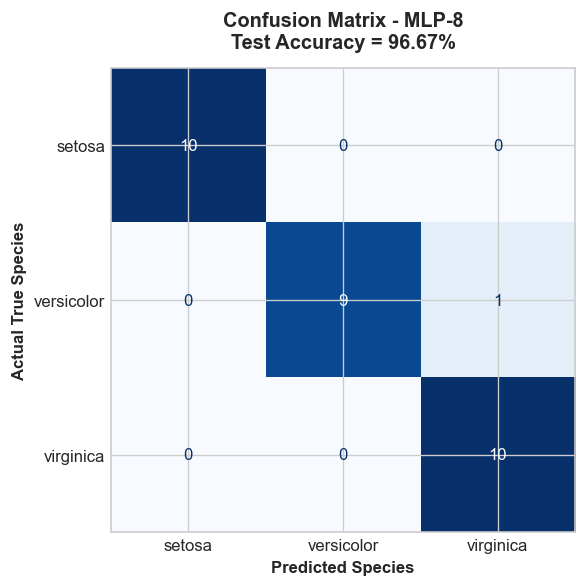

In [8]:
cm = confusion_matrix(y_test, selected_pred)
cm_df = pd.DataFrame(cm, index=[f"Actual {c}" for c in target_names], columns=[f"Pred {c}" for c in target_names])
display(cm_df)

print("\nClassification Report:")
print(classification_report(y_test, selected_pred, target_names=target_names, digits=4))

# Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', ax=ax, colorbar=False, values_format='d')
ax.set_title(f'Confusion Matrix - {selected_short}\nTest Accuracy = {selected_acc*100:.2f}%', fontweight='bold', pad=12)
ax.set_xlabel('Predicted Species', fontweight='bold')
ax.set_ylabel('Actual True Species', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Step 8: Comparative Visualizations (CV Accuracy & Convergence Loss)

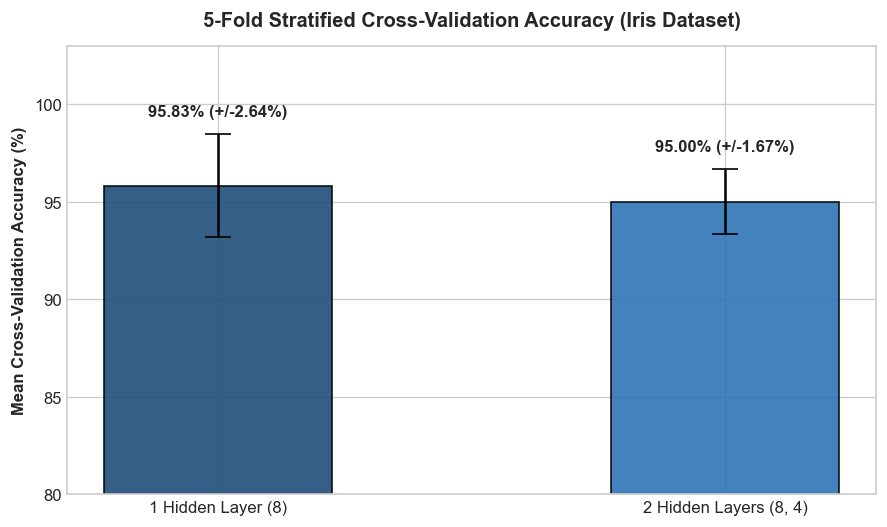

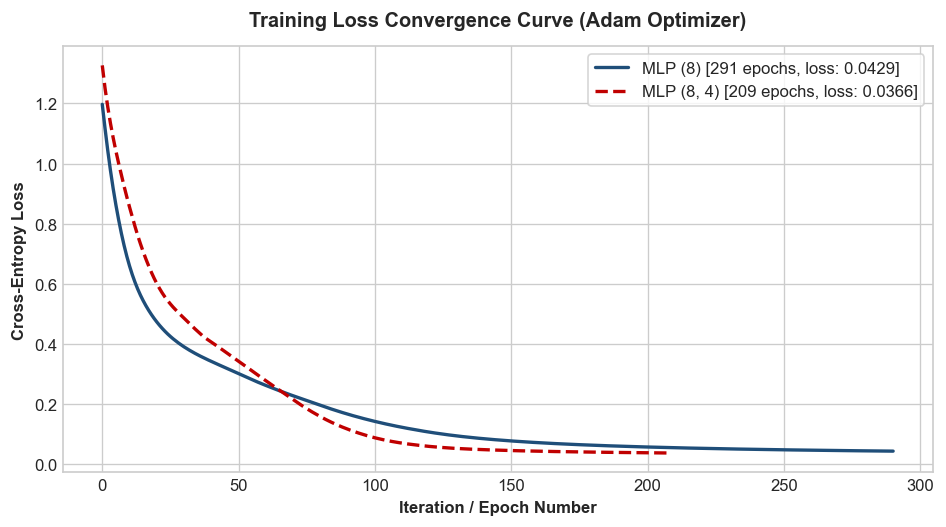

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
architectures = ['1 Hidden Layer (8)', '2 Hidden Layers (8, 4)']
means = [mean_cv_8 * 100, mean_cv_8_4 * 100]
stds = [std_cv_8 * 100, std_cv_8_4 * 100]
colors = ['#1F4E79', '#2E74B5']

bars = ax.bar(architectures, means, yerr=stds, capsize=8, color=colors, width=0.45, edgecolor='black', alpha=0.9)
ax.set_title('5-Fold Stratified Cross-Validation Accuracy (Iris Dataset)', fontweight='bold', pad=12)
ax.set_ylabel('Mean Cross-Validation Accuracy (%)', fontweight='bold')
ax.set_ylim(80, 103)

for bar, m, s in zip(bars, means, stds):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + s + 0.8, f"{m:.2f}% (+/-{s:.2f}%)", ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Training Loss Curves
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(mlp8_model.loss_curve_, color='#1F4E79', linewidth=2, label=f'MLP (8) [{len(mlp8_model.loss_curve_)} epochs, loss: {mlp8_model.loss_:.4f}]')
ax.plot(mlp8_4_model.loss_curve_, color='#C00000', linestyle='--', linewidth=2, label=f'MLP (8, 4) [{len(mlp8_4_model.loss_curve_)} epochs, loss: {mlp8_4_model.loss_:.4f}]')
ax.set_title('Training Loss Convergence Curve (Adam Optimizer)', fontweight='bold', pad=12)
ax.set_xlabel('Iteration / Epoch Number', fontweight='bold')
ax.set_ylabel('Cross-Entropy Loss', fontweight='bold')
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

## 10. Comparative Architectural Discussion & Key Learnings

1. **Network Depth vs. Breadth Dynamics:**
   - **Shallow Model (8,):** Projects the 4-dimensional input space directly into an 8-dimensional intermediate feature space, providing adequate capacity for linear segregation of Iris flower species.
   - **Deep Model (8, 4):** Implements hierarchical abstraction ($4 \rightarrow 8 \rightarrow 4 \rightarrow 3$) forming an informational bottleneck before output. It converged in fewer epochs (209 vs 291) with lower final loss (0.0366 vs 0.0429), but slightly lower cross-validation generalization (95.00% vs 95.83%).
2. **Model Complexity & Occam's Razor:**
   - The 1-layer model has 67 parameters, whereas the 2-layer model has 91 parameters (a 35.8% increase in complexity). On compact datasets ($N=150$), simpler models prevent subtle over-parameterization.

---
## 11. Step-by-Step Program Execution Flowchart (Sub-question ii)

| Execution Step | One-Line Technical Explanation |
| :--- | :--- |
| **1. Load Dataset** | Loads 150 instances and 4 morphological features via `sklearn.datasets.load_iris()`. |
| **2. Separate X & y** | Extracts 4 numerical features into matrix $X$ and species labels ($0, 1, 2$) into vector $y$. |
| **3. Stratified Split** | Splits into 80% train ($N=120$) and 20% test ($N=30$) preserving equal class balance. |
| **4. Feature Scaling** | Standardizes features with `StandardScaler` inside pipelines for smooth gradient descent. |
| **5. Model 1 (MLP-8)** | Constructs MLP with 1 hidden layer of 8 ReLU neurons (67 trainable parameters). |
| **6. Model 2 (MLP-8-4)** | Constructs MLP with 2 hidden layers of 8 and 4 ReLU neurons (91 trainable parameters). |
| **7. Cross-Validation** | Performs 5-Fold Stratified K-Fold CV to compute generalization accuracy and fold variance. |
| **8. Compare Accuracy** | Contrasts mean CV accuracy, standard deviation, convergence epochs, and parameter counts. |
| **9. Select Better Model** | Selects Model 1 based on higher CV accuracy ($95.83\%$ vs $95.00\%$) and parsimony. |
| **10. Confusion Matrix** | Evaluates selected model on test split, computing $96.67\%$ accuracy and confusion matrix. |